### 1. Importing Necessary Libraries and Dataset

In [1]:
### Loading required Python libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    recall_score,
    precision_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score)

import warnings
warnings.filterwarnings("ignore")

In [2]:
### Loading the dataset
df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
### checking the stucture
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
round(df.describe(),2)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.00,4240.00,4135.00,4240.00,4211.00,4187.00,4240.00,4240.00,4240.00,4190.00,4240.00,4240.00,4221.00,4239.00,3852.00,4240.00
mean,0.43,49.58,1.98,0.49,9.01,0.03,0.01,0.31,0.03,236.70,132.35,82.90,25.80,75.88,81.96,0.15
std,0.50,8.57,1.02,0.50,11.92,0.17,0.08,0.46,0.16,44.59,22.03,11.91,4.08,12.03,23.95,0.36
min,0.00,32.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,107.00,83.50,48.00,15.54,44.00,40.00,0.00
25%,0.00,42.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,75.00,23.07,68.00,71.00,0.00
50%,0.00,49.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,234.00,128.00,82.00,25.40,75.00,78.00,0.00
75%,1.00,56.00,3.00,1.00,20.00,0.00,0.00,1.00,0.00,263.00,144.00,90.00,28.04,83.00,87.00,0.00
max,1.00,70.00,4.00,1.00,70.00,1.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00,1.00


In [6]:
### Droping unnecessary columns
df.drop(columns = "education",axis = 1,inplace = True)

In [7]:
### Renaming columns for better readability
df.rename(columns = {
    "male" : "gender_male",
    "cigsPerDay" : "cigarettes_per_day",
    "BPMeds" : "blood_pressure_Meds",
    "prevalentStroke" : "stroke_history",
    "prevalentHyp" : "hypertension",
    "totChol" : "total_cholesterol",
    "sysBP" : "systolic_blood_pressure",
    "diaBP" : "diastolic_blood_pressure",
    "heartRate" : "heart_rate"},
    inplace = True)

### 2. Data Preprocessing

In [8]:
### handling missing values
round(df.isna().sum()/len(df)*100,2)

gender_male                 0.00
age                         0.00
currentSmoker               0.00
cigarettes_per_day          0.68
blood_pressure_Meds         1.25
stroke_history              0.00
hypertension                0.00
diabetes                    0.00
total_cholesterol           1.18
systolic_blood_pressure     0.00
diastolic_blood_pressure    0.00
BMI                         0.45
heart_rate                  0.02
glucose                     9.15
TenYearCHD                  0.00
dtype: float64

these are percentage of missing values

In [9]:
### removing rows with NaN values
df.dropna(inplace = True)
df.shape

(3751, 15)

In [10]:
### seperating features (x) and target label (y)

x = df.drop(columns=['TenYearCHD'],axis = 1) 
y = df['TenYearCHD']

In [11]:
### splitting the dataset into training and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(f"training data : x_train_shape -{x_train.shape},  y_train_shape-{y_train.shape}")
print(f"testing data : x_test_shape -{x_test.shape},  y_test_shape-{y_test.shape}")

training data : x_train_shape -(2625, 14),  y_train_shape-(2625,)
testing data : x_test_shape -(1126, 14),  y_test_shape-(1126,)


In [12]:
### Noramlizing using standardscaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

###  3. Exploratory Data Analysis (EDA)

In [13]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3179
1     572
Name: count, dtype: int64

In [14]:
round(df["TenYearCHD"].value_counts(normalize = True)*100,2)

TenYearCHD
0    84.75
1    15.25
Name: proportion, dtype: float64

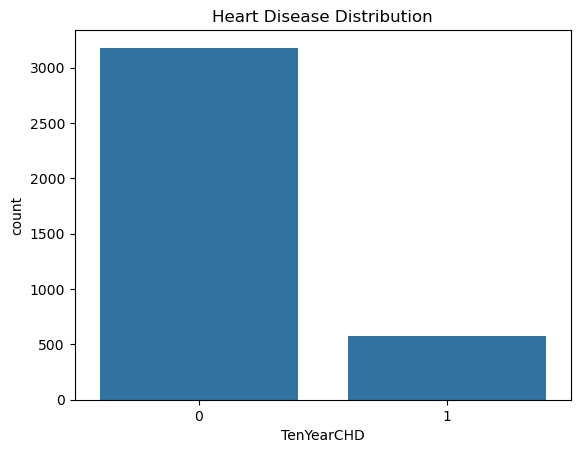

In [15]:
### class distribution of heart cases
sns.countplot(df,x = "TenYearCHD")
plt.title("Heart Disease Distribution")
plt.show()

#### Interpretation

The Dataset is imbalanced. Approximately 85% of the patients do not have coronary heart disease within 10 years,
while 16% develop CHD.

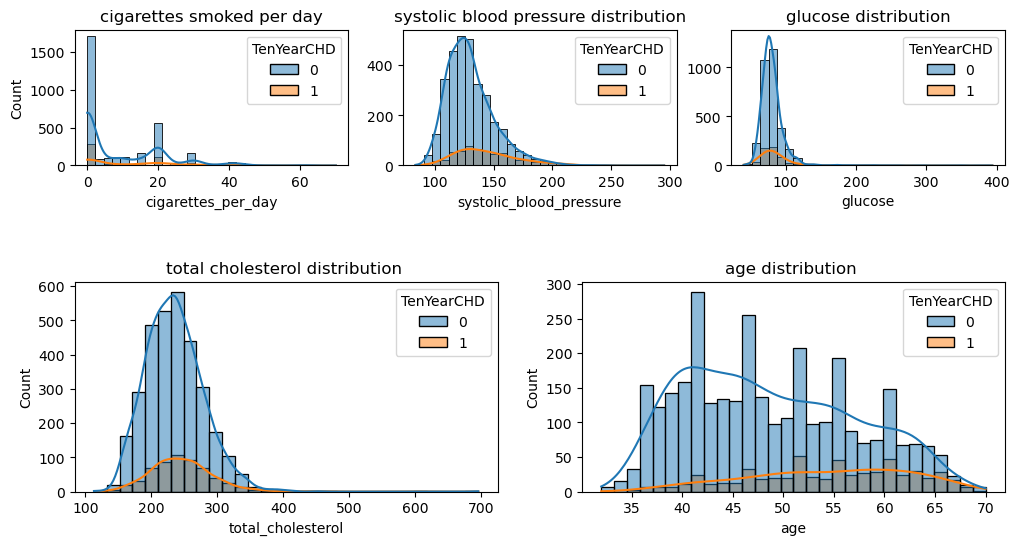

In [16]:
plt.figure(figsize = (12,6))

plt.subplot(3,3,1)
sns.histplot(df,x = "cigarettes_per_day",kde = True,hue = "TenYearCHD",bins = 30)
plt.title("cigarettes smoked per day")

plt.subplot(3,3,2)
sns.histplot(df,x = "systolic_blood_pressure",kde = True,hue = "TenYearCHD",bins = 30)
plt.ylabel("")
plt.title("systolic blood pressure distribution")

plt.subplot(3,3,3)
sns.histplot(df,x = "glucose",kde = True,hue = "TenYearCHD",bins = 30)
plt.ylabel("")
plt.title("glucose distribution")

plt.subplot(2,2,3)
sns.histplot(df,x = "total_cholesterol",kde = True,hue = "TenYearCHD",bins = 30)
plt.title("total cholesterol distribution ")

plt.subplot(2,2,4)
sns.histplot(df,x = "age",kde = True,hue = "TenYearCHD",bins = 30)
plt.title("age distribution ")

plt.show()

#### Interpretation

1 .cigarettes smoked per day 
- Smoking is associated with increased risk of heart disease. However the relation is not linear

2 . Higher systolic blood pressure is associated with CHD
- Most non-CHD patients are concentrated around 110-140 mmHg.
- Indiviuals with elevated systolic blood pressure, shows the greater likelibhood of developing heart disease.

3 .Glucose levels shows positive relation ship
- CHD cases tend to occur more frequently at higher glucose levels.
- Elevated glucose levels are associated with high risk of coronary heart disease.

4 .Total Cholesterol shows moderate influence
- Both classes peak around similar cholesterol levels.
- CHD patients appear slightly more common in higher cholesterol range

5 .Age is a strong risk factor
- Patients with CHD(1) are concenterated at higher ages.
- Number of CHD cases increases noticeably after approximately 50 years of age.
- Older individuals appears to have greater risk of developing coronary heart disease.

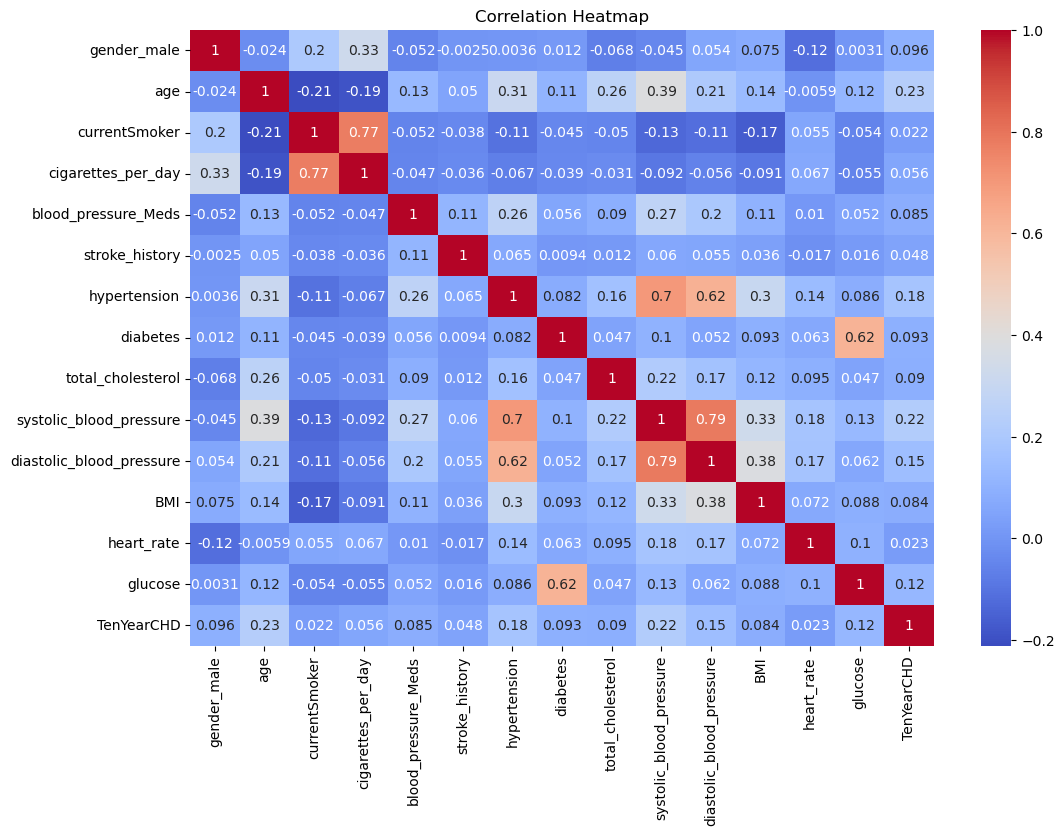

In [17]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(),annot = True,cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Interpretation

- Correlation analysis shows age(0.23), systolic blood pressure(0.22) and hypertension(0.18) were the strongest predictors 
of 10 year coronary heart disease risk.

- Glucose level, diabetes and  cholesterol also shows positive association with CHD.

- Strong correlations were observed among related healt indicators such as systolic and diastolic blood pressure(0.79).

### 4. Model Training using Logistic Regression

In [18]:
### training the model
model = LogisticRegression(random_state = 42)
model.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [19]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [20]:
### calculating scores( roc_auc_score, recall_score)
roc_auc = roc_auc_score(y_test,y_prob)
recall = recall_score(y_test,y_pred)

In [21]:
print(f"Accuracy Score : {round(accuracy_score(y_test,y_pred),2)}")
print(f"F1 : { round(f1_score(y_test,y_pred),2)}")
print(f"Precision : {precision_score(y_test,y_pred)}")
print(f"Recall : { round(recall_score(y_test,y_pred),2)}")
print(f"ROC-AUC Score : {round(roc_auc,2)}")
print("Classification Report :")
print(classification_report(y_test,y_pred))
print("Confusion Matrix :")
print(confusion_matrix(y_test,y_pred))

Accuracy Score : 0.83
F1 : 0.12
Precision : 0.52
Recall : 0.07
ROC-AUC Score : 0.72
Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.68      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126

Confusion Matrix :
[[926  12]
 [175  13]]


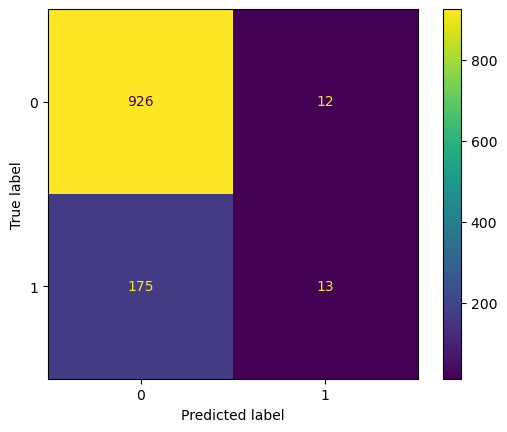

In [22]:
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### interpretation 

- Logistic regression model trained on this imbalanced data shows confusion matrix and classification report giving
poor recall score for class 1.

- To resove this, using Synthetic Minority Over-sampleing Technique(SMOTE). This technique forces the model to learn the mathematical
boundaries of minority class.

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

smote_model = LogisticRegression(random_state = 42)
smote_model.fit(x_train_smote,y_train_smote)

LogisticRegression(random_state=42)

In [24]:
print(f"Before SMOTE :{y_train.value_counts()}")

Before SMOTE :TenYearCHD
0    2241
1     384
Name: count, dtype: int64


In [25]:
print(f"After SMOTE :{ y_train_smote.value_counts()}")

After SMOTE :TenYearCHD
0    2241
1    2241
Name: count, dtype: int64


In [26]:
y_pred_smote = smote_model.predict(x_test)
y_prob_smote = smote_model.predict_proba(x_test)[:,1]

In [27]:
### calculating scores on balanced data
roc_auc_smote = roc_auc_score(y_test,y_prob_smote)
recall_smote = recall_score(y_test,y_pred_smote)

### 5. Model Evaluation and Prediction

In [28]:
print(f"Accuracy Score : {round(accuracy_score(y_test,y_pred_smote),2)}")
print(f"F1 : { round(f1_score(y_test,y_pred_smote),2)}")
print(f"Precision :{round(precision_score(y_test,y_pred_smote),2)}")
print(f"Recall : { round(recall_score(y_test,y_pred_smote),2)}")
print(f"ROC-AUC Score : {round(roc_auc_smote,2)}")
print("Classification Report:")
print(classification_report(y_test,y_pred_smote))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_smote))

Accuracy Score : 0.69
F1 : 0.41
Precision :0.3
Recall : 0.65
ROC-AUC Score : 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       938
           1       0.30      0.65      0.41       188

    accuracy                           0.69      1126
   macro avg       0.61      0.67      0.60      1126
weighted avg       0.81      0.69      0.73      1126

Confusion Matrix:
[[656 282]
 [ 66 122]]


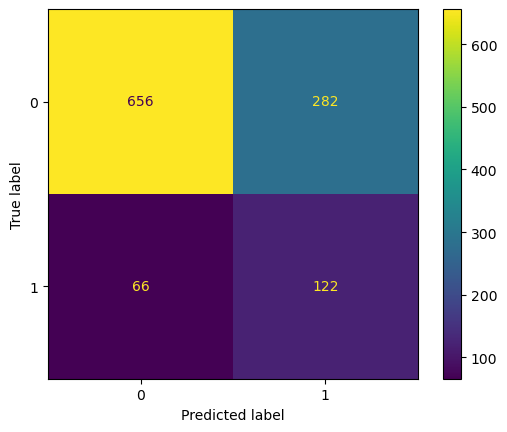

In [29]:
cm = confusion_matrix(y_test,y_pred_smote)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [30]:
print(f"Recall Score before SMOTE : {round(recall*100,2)} %")
print(f"Recall Score after SMOTE : {round(recall_smote*100,2)} %")

Recall Score before SMOTE : 6.91 %
Recall Score after SMOTE : 64.89 %


### interpretation 

- The confusion matrix : after applying SMOTE to balance the training data, the confusion matrix shows
a significant shift.While the model now produces more False Positives(predicting disease where there is none),
is successfully capturing a much higher number of True positives (correctly identifying actual heart disease case).

- In a clinical setting , a False Positive simply leads to further medical testing , whereas a False Negative (sending a sick patient home)
is fatal. The model correctly prioritizes clinical safety.

- The classification report(recall vs precision) : the defining metric of this balanced model is the improved recall for class 1 
(Coronary Heart Diesese).Imbalanced data inherently favors high Presision for the majority class at the expense of minority class recall.

- By addressing the data imbalance, the model trades a nominal amount of overall accuracy to esnure that the algorithm actively identifies the 
statistical markers of high-risk patients, making it a functionally viable diagnostic tool.

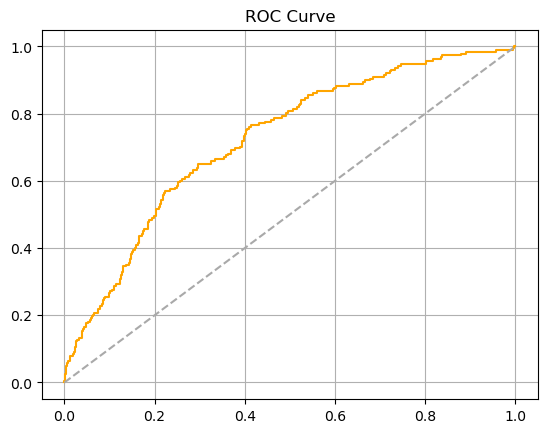

In [31]:
fpr_smote,tpr_smote,_ = roc_curve(y_test, y_prob_smote)
plt.title("ROC Curve")
plt.plot(fpr_smote,tpr_smote, color = "orange")
plt.plot([0,1], [0,1], color = "darkgrey", linestyle = "--")
plt.grid()
plt.show()

In [32]:
### prediction

### Picking a random row number based on the size of your x_test array
random_index = np.random.randint(0, len(x_test))

### Extract that single patient's row 
unseen_patient = x_test[random_index].reshape(1, -1)


print(f" PATIENT VITALS (Row {random_index})")

unseen_patient_scaled = scaler.transform(unseen_patient)

prediction = smote_model.predict(unseen_patient_scaled)
probability = smote_model.predict_proba(unseen_patient_scaled)[0][1]

print(" DIAGNOSTIC PREDICTION")

if prediction[0] == 1:
    print("The model flags this patient as having a high risk of developing")
    print("Coronary Heart Disease (CHD) in the next 10 years.")
else:
    print("The model flags this patient as having a low risk of developing")
    print("Coronary Heart Disease (CHD) in the next 10 years.")

print(f"\nStatistical Probability of CHD: {probability}")

 PATIENT VITALS (Row 465)
 DIAGNOSTIC PREDICTION
The model flags this patient as having a low risk of developing
Coronary Heart Disease (CHD) in the next 10 years.

Statistical Probability of CHD: 0.0013062430138540454


## Project Conclusion

- By conducting thorough Exploratory Data Analysis (EDA) on the Framingham dataset, a critical class imbalance was identified,
which initially caused the Logistic Regression algorithm to heavily bias its predictions toward healty outcomes.

- Through the implementation of the Synthetic Minority Over-sampling Techinque (SMOTE) on the training set, the algorithm was forced to mathematically
weigh the minority class , resulting in a dramatic improvement in identifying at-risk patients.


- Ultimately. the balanced Logistic Regression model succesfully detects hidden cardiovascular risk factor such as age, systolic
blood pressure and smoking habits-proving that with proper data preprocessing and validation methodologies, machine learinig 
can be effectively deployed as a powerful early-detection system in healthcare analysis.